In [14]:
%load_ext autoreload
%autoreload 2

from peak_extraction.extract_peaks import plaxco_gauss_fit, poly_linear_fit, baseline_peak_fit, smooth_data, \
    get_background_range, second_diff_matrix, huber_reweighted_lcurve
from peak_extraction.extract_peaks import (
    choose_lambda_weighted_bl, choose_lambda_lcurve, single_gaussian, get_background_range,
    make_smoother_D2, second_diff_matrix, choose_lambda_area, huber_reweighted_lcurve
)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
from pybaselines import Baseline, utils
from matplotlib.colors import to_hex
from matplotlib.ticker import MaxNLocator

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [15]:
plt.rcParams.update({
    "figure.dpi": 300,
    "savefig.dpi": 600,
    "font.size": 10,
    "axes.labelsize": 16,
    "axes.titlesize": 16,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "axes.linewidth": 1.0,
    "xtick.labelbottom": False,
    "ytick.labelleft": False,
    "xtick.major.width": 1.0,
    "ytick.major.width": 1.0,
    "xtick.major.size": 4.0,
    "ytick.major.size": 4.0,
    "legend.fontsize": 9,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "mathtext.default": "it",
    "axes.spines.top": False,
    "axes.spines.right": False,
})

plt.rcParams["figure.subplot.left"]   = 0.22
plt.rcParams["figure.subplot.right"]  = 0.98
plt.rcParams["figure.subplot.bottom"] = 0.12
plt.rcParams["figure.subplot.top"]    = 0.96
plt.rcParams["figure.subplot.hspace"] = 0.35

def multi_obj_error(y, g, D):
    J1 = np.linalg.norm(y-g)**2
    J2 = np.linalg.norm(D@g)**2
    return J1, J2

In [16]:
# ==================================================
# Lambda color settings: edit these per panel
# ==================================================
# Each panel gets its own centered lambda range and representative lambda fractions.
# decades_each_side = 4.0 means lambda_opt * 1e-4 to lambda_opt * 1e4.
# fractions are positions through the displayed lambda grid, not absolute lambda values.
LAMBDA_PLOT_SETTINGS = {
    "smoothing": {
        "decades_each_side": 6.0,
        "fractions": (0.10, 0.30, 0.60, 0.70),
        "show_reference_trace": False,  # False removes thin gray raw trace under colored curves.
    },
    "baseline": {
        "decades_each_side": 4.0,
        "fractions": (0.10, 0.25, 0.4, 0.75),
        "show_reference_trace": False,  # False removes thin gray smoothed trace under colored curves.
    },
    "peak": {
        "decades_each_side": 4.0,
        "fractions": (0.10, 0.30, 0.75, 0.85),
        "show_reference_trace": False,  # False removes thin gray peak-region trace under colored curves.
    },
}

# Number of lambda curves used for each colored sweep.
N_LAMBDA_PLOT = 150

TURBO_CMAP = cm.get_cmap("turbo").copy()
# Make out-of-range and invalid values visibly non-gray if something slips through.
TURBO_CMAP.set_bad(TURBO_CMAP(0.5))
TURBO_CMAP.set_under(TURBO_CMAP(0.0))
TURBO_CMAP.set_over(TURBO_CMAP(1.0))


def lambda_setting(step, key, default=None):
    """Read a per-panel lambda plotting setting."""
    return LAMBDA_PLOT_SETTINGS.get(step, {}).get(key, default)


def lambda_grid_around(lam_opt, step=None, decades_each_side=None, n=None):
    """
    Return a log-spaced lambda grid centered on lam_opt in log10 space.

    If step is provided, the default decades_each_side is read from
    LAMBDA_PLOT_SETTINGS[step]["decades_each_side"].
    """
    if decades_each_side is None:
        decades_each_side = lambda_setting(step, "decades_each_side", 4.0)
    if n is None:
        n = N_LAMBDA_PLOT

    lam_opt = float(lam_opt)
    if not np.isfinite(lam_opt) or lam_opt <= 0:
        raise ValueError(f"lam_opt must be positive and finite, got {lam_opt}")

    lo = np.log10(lam_opt) - float(decades_each_side)
    hi = np.log10(lam_opt) + float(decades_each_side)
    return np.logspace(lo, hi, int(n))


def lambda_norm_around(lam_opt, step=None, decades_each_side=None):
    """
    LogNorm whose midpoint in log10 space is lam_opt.
    """
    if decades_each_side is None:
        decades_each_side = lambda_setting(step, "decades_each_side", 4.0)

    lam_opt = float(lam_opt)
    vmin = lam_opt * 10 ** (-float(decades_each_side))
    vmax = lam_opt * 10 ** ( float(decades_each_side))
    return mcolors.LogNorm(vmin=vmin, vmax=vmax)


def lambda_color(lam, norm, cmap=TURBO_CMAP):
    """
    Robust scalar lambda -> RGBA.
    Clips to the norm range so Matplotlib never falls back to gray for over/under/bad values.
    """
    lam = float(lam)
    if not np.isfinite(lam) or lam <= 0:
        return cmap(0.5)

    lam = np.clip(lam, norm.vmin, norm.vmax)
    val = float(norm(lam))
    if not np.isfinite(val):
        val = 0.5
    return cmap(val)


def lambda_colors(lams, norm, cmap=TURBO_CMAP):
    """Vector/list version of lambda_color."""
    return [lambda_color(lam, norm, cmap=cmap) for lam in np.asarray(lams, dtype=float)]


def make_colored_line_collection(x, y, lams, norm, linewidth=2.0, cmap=TURBO_CMAP, **kwargs):
    """
    Build a LineCollection with explicit RGBA segment colors.

    This avoids the occasional thin gray LineCollection artifacts that can appear when using
    set_array + cmap + norm, especially if any objective value is NaN/inf or outside limits.
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    lams = np.asarray(lams, dtype=float)

    good = np.isfinite(x) & np.isfinite(y) & np.isfinite(lams) & (lams > 0)
    x = x[good]
    y = y[good]
    lams = lams[good]

    if x.size < 2:
        raise RuntimeError("Too few finite points to build colored line collection.")

    pts = np.column_stack([x, y]).reshape(-1, 1, 2)
    segments = np.concatenate([pts[:-1], pts[1:]], axis=1)
    seg_lams = 0.5 * (lams[:-1] + lams[1:])
    seg_colors = lambda_colors(seg_lams, norm, cmap=cmap)

    return LineCollection(
        segments,
        colors=seg_colors,
        linewidth=linewidth,
        **kwargs,
    )


def fraction_indices(n, fractions=None, step=None):
    """
    Pick indices by fractional position through an array.
    This preserves the 'fraction of lambdas' behavior, with per-panel settings.
    """
    if fractions is None:
        fractions = lambda_setting(step, "fractions", (0.10, 0.30, 0.60, 0.70))

    n = int(n)
    idx = []
    for f in fractions:
        f = float(np.clip(f, 0.0, 1.0))
        idx.append(int(round(f * (n - 1))))
    return np.unique(idx).astype(int)# ==================================================
# Optimal-curve styling
# ==================================================
# Keep the objective-plot points in their original colormap style, but make the
# selected fitted curve in the upper subplot read clearly as the optimum.
OPTIMAL_CURVE_LW = 1.6
OPTIMAL_CURVE_WHITE_HALO_LW = 4.0
OPTIMAL_CURVE_DARK_HALO_LW = 3.0
OPTIMAL_CURVE_DARK_HALO_ALPHA = 1.0


def plot_optimal_lambda_curve(
    ax,
    x,
    y,
    *,
    color,
    label=None,
    lw=OPTIMAL_CURVE_LW,
    zorder=8,
):
    """
    Draw the selected lambda curve with its original color, but with a subtle
    backing stroke so it stands out from the neighboring lambda sweeps.

    The white stroke separates the curve from nearby traces; the dark stroke
    gives contrast on transparent/exported backgrounds. The final colored line
    remains the original lambda color.
    """
    ax.plot(
        x,
        y,
        color="white",
        lw=OPTIMAL_CURVE_WHITE_HALO_LW,
        alpha=0.95,
        solid_capstyle="round",
        solid_joinstyle="round",
        zorder=zorder - 2,
    )
    ax.plot(
        x,
        y,
        color="black",
        lw=OPTIMAL_CURVE_DARK_HALO_LW,
        alpha=OPTIMAL_CURVE_DARK_HALO_ALPHA,
        solid_capstyle="round",
        solid_joinstyle="round",
        zorder=zorder - 1,
    )
    return ax.plot(
        x,
        y,
        color=color,
        lw=lw,
        label=label,
        solid_capstyle="round",
        solid_joinstyle="round",
        zorder=zorder,
    )[0]


/var/folders/j4/r_tjgvn15y16clpqr_5grrbc0000gn/T/ipykernel_36593/3804611580.py:28: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  TURBO_CMAP = cm.get_cmap("turbo").copy()


In [17]:
def read_csv(path, channel=0):
    df = pd.read_csv(path, skiprows=6, encoding="utf-16").apply(pd.to_numeric, errors='coerce').dropna()
    volts = df.iloc[:, 0].astype(float).to_numpy()
    currents = df.iloc[:, 1::2].dropna(how='all').astype(float).to_numpy().T
    return volts, currents[channel]

path = '/Users/Max_1/Soh Lab/echem/05_ATP Calib Curve Day 5/150hz-15.csv'
volts, current = read_csv(path, channel=0)
lam_lcurve, g, params_lcurve = choose_lambda_lcurve(current, n_grid=150)
lam_bl, background, params_bl = choose_lambda_area(g, volts, search_space=150)
lower, upper, _ = get_background_range(g, rel_height=1.0)
smoother = make_smoother_D2(len(current))
D = second_diff_matrix(len(current))

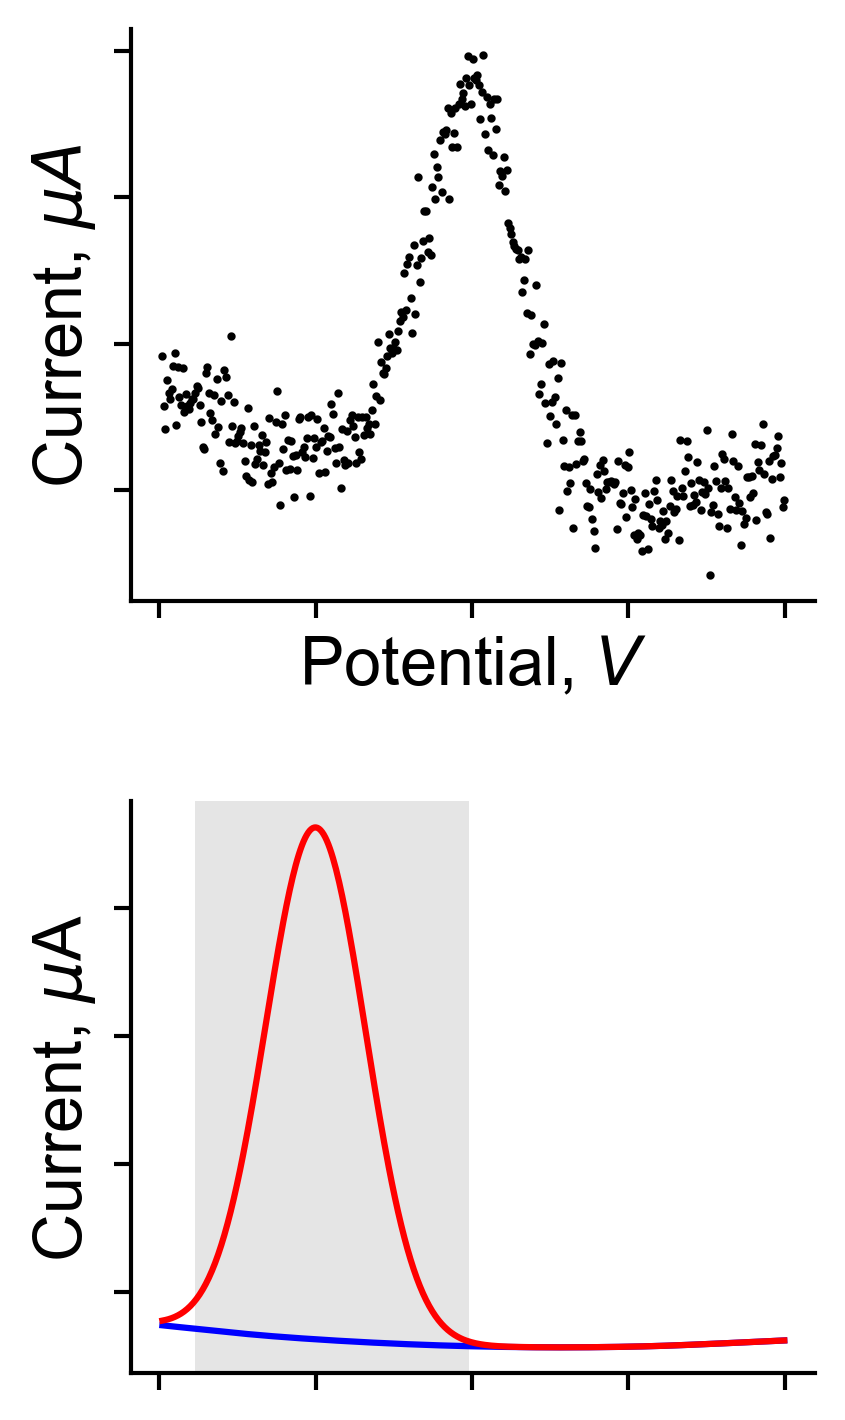

In [18]:
fig, axes = plt.subplots(
    2, 1,
    figsize=(3, 8*2/3),
)

ax = axes[0]
ax.scatter(volts, current, s=1, color="black", zorder=3)
ax.set_xlabel(r"Potential, $V$")
ax.set_ylabel(r"Current, $\mu A$")

ax = axes[1]
good_signal = background + single_gaussian(volts, 0.2, -0.2, 0.032)
lower1, upper1, _ = get_background_range(good_signal, rel_height=1.0)
ax.plot(volts, background, color='blue')
ax.plot(volts, good_signal, color='red')
ax.set_ylabel(r"Current, $\mu$A")
ax.axvspan(
    volts[lower1], volts[upper1],
    color="gray",
    alpha=0.2,
    linewidth=0,
)

for ax in axes:
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

y_ticks = axes[0].get_yticks()
y_lim = axes[0].get_ylim()
x_ticks = axes[0].get_xticks()
x_lim = axes[0].get_xlim()

save_path = '/Users/Max_1/Soh Lab/figures/derpsalsa/1a.png'
plt.savefig(save_path, transparent=True)
plt.show()

/var/folders/j4/r_tjgvn15y16clpqr_5grrbc0000gn/T/ipykernel_36593/1090633423.py:34: RuntimeWarning: divide by zero encountered in matmul
  J2 = np.linalg.norm(D@g)**2
/var/folders/j4/r_tjgvn15y16clpqr_5grrbc0000gn/T/ipykernel_36593/1090633423.py:34: RuntimeWarning: overflow encountered in matmul
  J2 = np.linalg.norm(D@g)**2
/var/folders/j4/r_tjgvn15y16clpqr_5grrbc0000gn/T/ipykernel_36593/1090633423.py:34: RuntimeWarning: invalid value encountered in matmul
  J2 = np.linalg.norm(D@g)**2


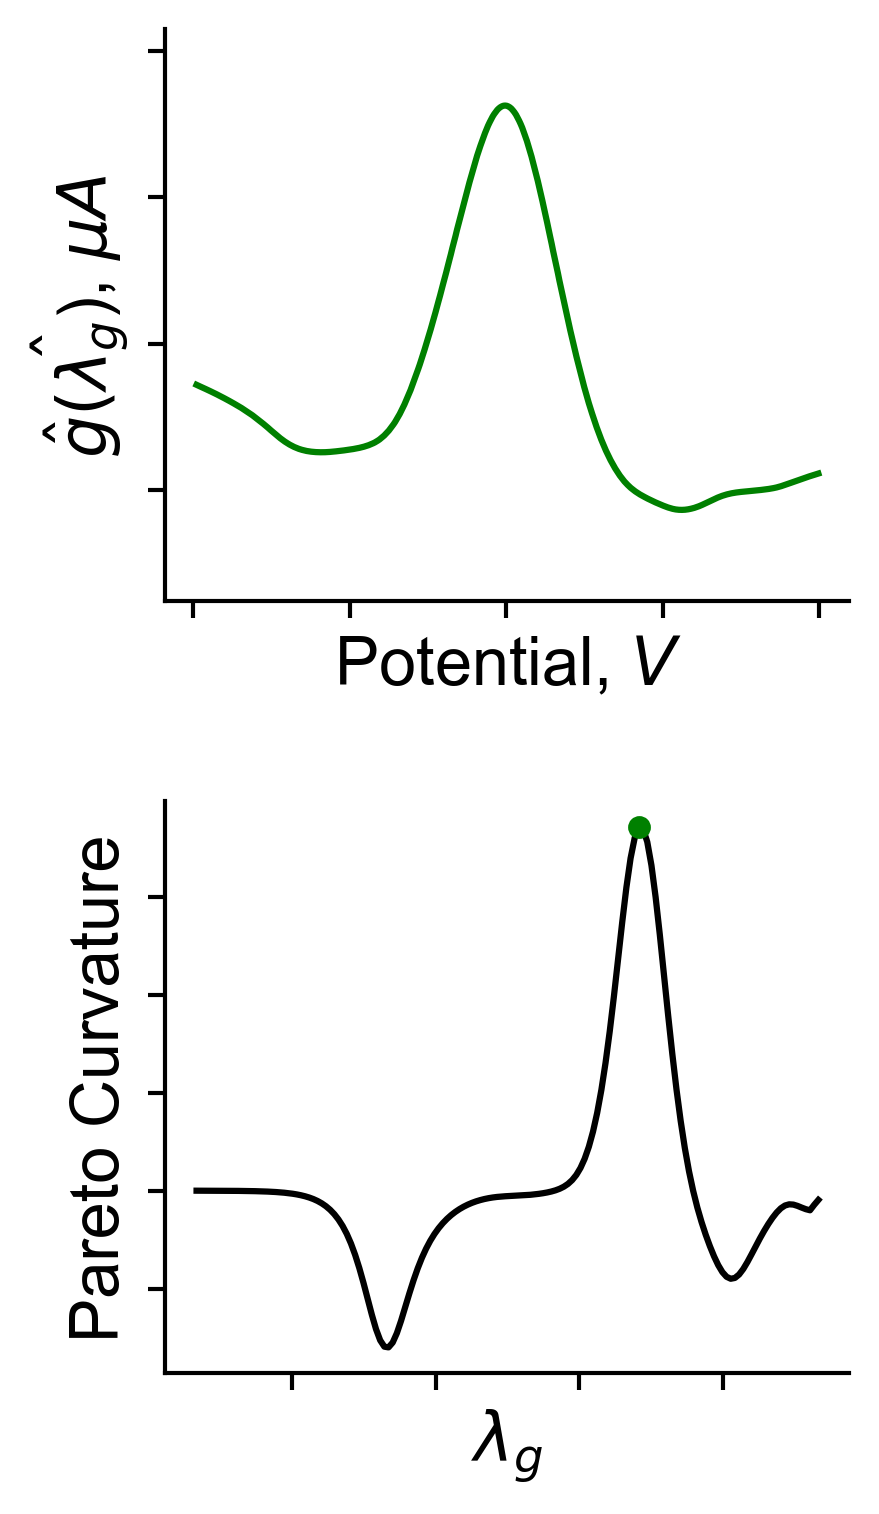

In [19]:
lams = params_lcurve['lams']
kappa = params_lcurve['kappa']
y = current
J1s = []
J2s = []
gs = []

for lam in lams:
    g_temp = smooth_data(y, lam)
    gs.append(g_temp)
    J1, J2 = multi_obj_error(y, g_temp, D)
    J1s.append(J1)
    J2s.append(J2)

fig, axes = plt.subplots(
    2, 1,
    figsize=(3, 8*2/3),
)

ax = axes[0]
ax.plot(volts, g, color="green")
ax.set_xlabel(r"Potential, $V$")
ax.set_ylabel(r"$\hat{g}(\hat{\lambda_g}$), $\mu A$")
ax.set_yticks(y_ticks)
ax.set_ylim(y_lim)

ax = axes[1]
ax.plot(lams, kappa, color='black')
lcurve_idx = np.argmin(np.abs(lams - lam_lcurve))
ax.scatter(lam_lcurve, kappa[lcurve_idx], s=20, zorder=3, color='green')
ax.set_xscale('log')
ax.set_xlabel(r"$\lambda_g$")
ax.set_ylabel(r"Pareto Curvature")

# styling
for ax in axes:
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

save_path = '/Users/Max_1/Soh Lab/figures/derpsalsa/1b.png'
plt.savefig(save_path, transparent=True)
plt.show()

/var/folders/j4/r_tjgvn15y16clpqr_5grrbc0000gn/T/ipykernel_36593/1090633423.py:34: RuntimeWarning: divide by zero encountered in matmul
  J2 = np.linalg.norm(D@g)**2
/var/folders/j4/r_tjgvn15y16clpqr_5grrbc0000gn/T/ipykernel_36593/1090633423.py:34: RuntimeWarning: overflow encountered in matmul
  J2 = np.linalg.norm(D@g)**2
/var/folders/j4/r_tjgvn15y16clpqr_5grrbc0000gn/T/ipykernel_36593/1090633423.py:34: RuntimeWarning: invalid value encountered in matmul
  J2 = np.linalg.norm(D@g)**2


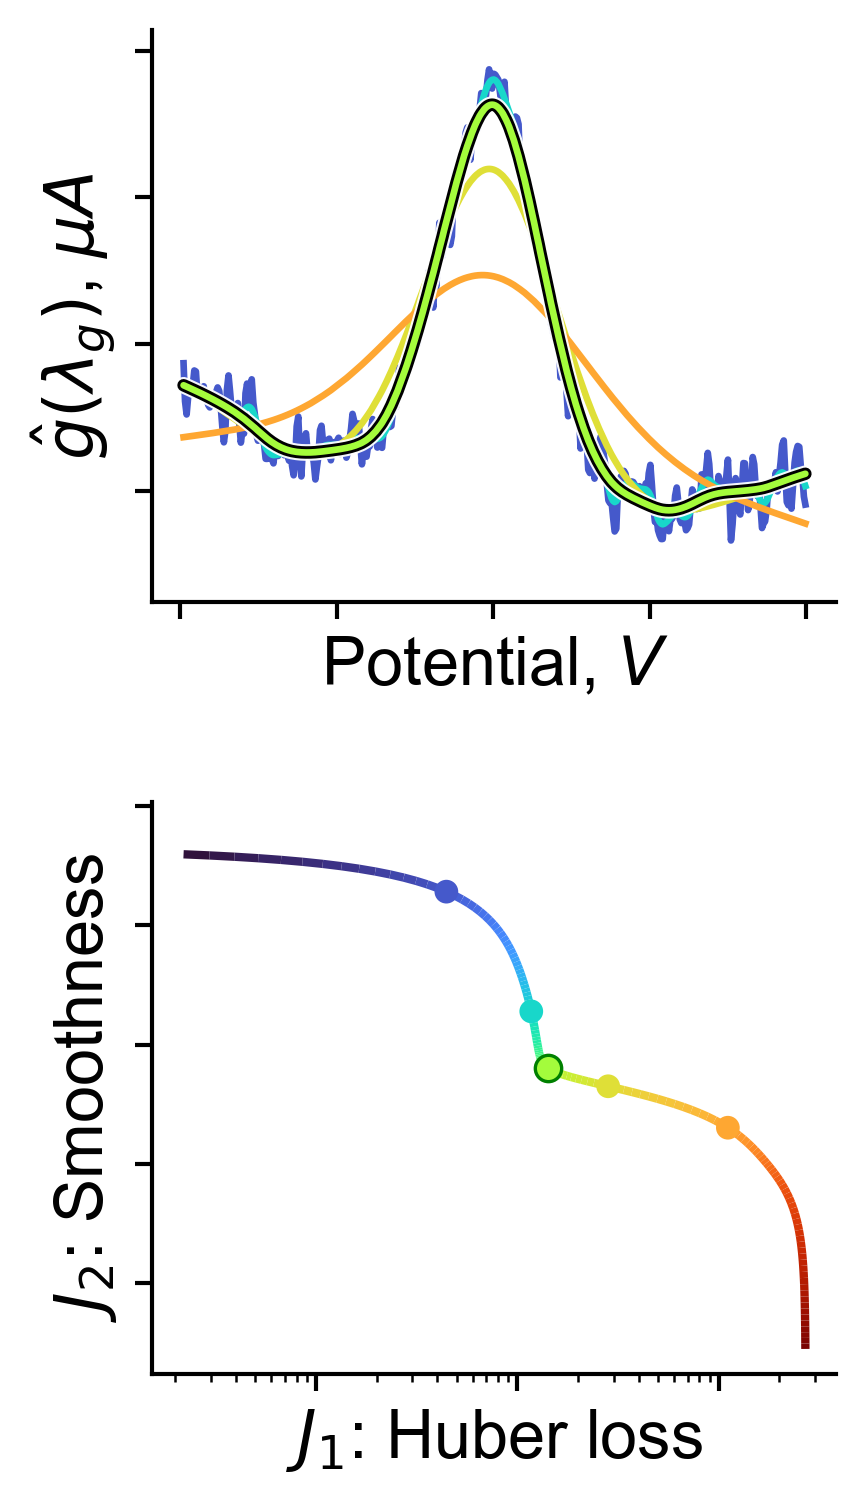

smoothing decades each side: 6.0
smoothing fractions: (0.1, 0.3, 0.6, 0.7)
smoothing lambda color position: 0.500


In [20]:

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection

# --------------------------------------------------
# centered lambda grid around the already-selected optimum
# --------------------------------------------------
STEP = "smoothing"
lams = lambda_grid_around(lam_lcurve, step=STEP)
norm = lambda_norm_around(lam_lcurve, step=STEP)
cmap = TURBO_CMAP

y = current
D = second_diff_matrix(len(current))

J1s = []
J2s = []
gs = []

for lam in lams:
    g_temp = smooth_data(y, lam)
    gs.append(g_temp)
    J1, J2 = multi_obj_error(y, g_temp, D)
    J1s.append(J1)
    J2s.append(J2)

J1s = np.asarray(J1s)
J2s = np.asarray(J2s)
gs = np.asarray(gs)

# representative lambdas chosen by fractional position across the centered grid
rep_idx = fraction_indices(len(lams), step=STEP)

# selected lambda is plotted separately and should map to the center/yellow of the cmap
lcurve_idx = np.argmin(np.abs(lams - lam_lcurve))
rep_idx = rep_idx[rep_idx != lcurve_idx]

# --------------------------------------------------
# build colored Pareto frontier
# --------------------------------------------------
pts = np.column_stack([J1s, J2s]).reshape(-1, 1, 2)
segments = np.concatenate([pts[:-1], pts[1:]], axis=1)

lc = make_colored_line_collection(J1s, J2s, lams, norm, linewidth=2.0)

# --------------------------------------------------
# plot
# --------------------------------------------------
fig, axes = plt.subplots(
    2, 1,
    figsize=(3, 8*2/3),
)

ax = axes[0]
if lambda_setting(STEP, "show_reference_trace", False):
    ax.plot(volts, y, color="black", lw=0.3, alpha=0.35, label="raw")

for idx in rep_idx:
    ax.plot(
        volts,
        gs[idx],
        color=lambda_color(lams[idx], norm),
        lw=1.6,
        label=rf"$\lambda={lams[idx]:.2e}$"
    )

plot_optimal_lambda_curve(
    ax,
    volts,
    gs[lcurve_idx],
    color=lambda_color(lam_lcurve, norm),
    label=rf"$\hat{{\lambda}}={lam_lcurve:.2e}$"
)

ax.set_xlabel(r"Potential, $V$")
ax.set_ylabel(r"$\hat{g}(\lambda_g)$, $\mu A$")
ax.set_yticks(y_ticks)
ax.set_ylim(y_lim)

ax = axes[1]
ax.add_collection(lc)

ax.scatter(
    J1s[rep_idx],
    J2s[rep_idx],
    color=[lambda_color(lams[i], norm) for i in rep_idx],
    s=22,
    zorder=3
)

ax.scatter(
    J1s[lcurve_idx],
    J2s[lcurve_idx],
    color=[lambda_color(lam_lcurve, norm)],
    s=40,
    edgecolors="green",
    linewidths=0.8,
    zorder=4
)

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r"$J_1$: Huber loss")
ax.set_ylabel(r"$J_2$: Smoothness")

ymin, ymax = ax.get_ylim()
ax.set_ylim(ymin, ymax * 5)

# styling
for ax in axes:
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

save_path = '/Users/Max_1/Soh Lab/figures/derpsalsa/1c.png'
plt.savefig(save_path, transparent=True)
plt.show()

print(f"smoothing decades each side: {lambda_setting(STEP, 'decades_each_side')}")
print(f"smoothing fractions: {lambda_setting(STEP, 'fractions')}")
print(f"smoothing lambda color position: {float(norm(lam_lcurve)):.3f}")



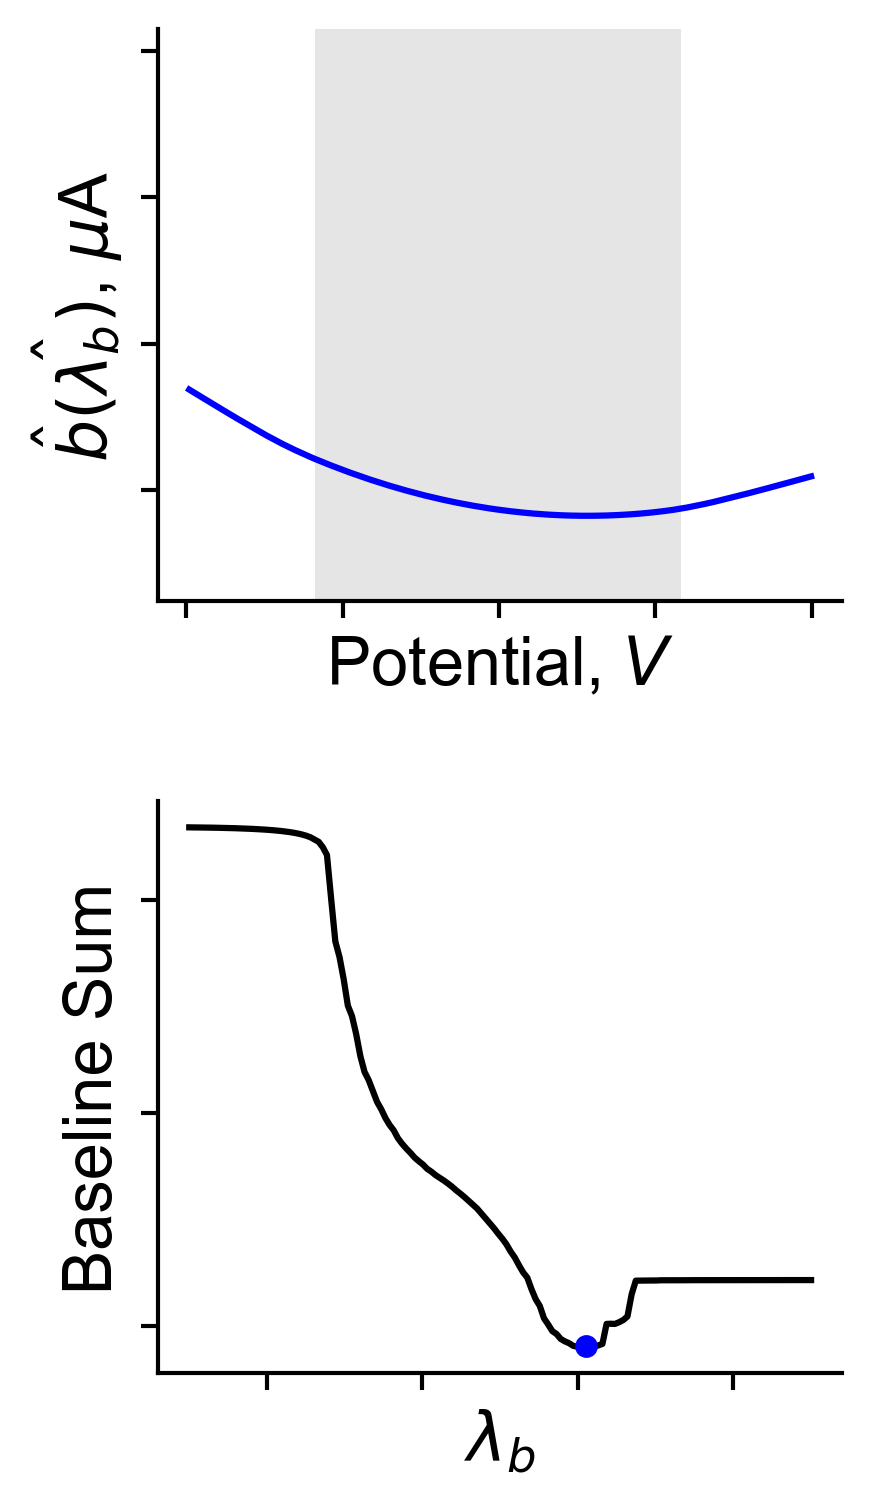

In [21]:
lams = params_bl['lams']
areas = params_bl['areas']
y = current
mask = np.ones_like(current)
mask[lower:upper] = 0


fig, axes = plt.subplots(
    2, 1,
    figsize=(3, 8*2/3),
)

ax = axes[0]
ax.plot(volts, background, color="blue")
ax.axvspan(
    volts[lower], volts[upper],
    color="gray",
    alpha=0.2,
    linewidth=0,
)
ax.set_xlabel(r"Potential, $V$")
ax.set_ylabel(r"$\hat{b}(\hat{\lambda_b})$, $\mu$A")
ax.set_yticks(y_ticks)
ax.set_ylim(y_lim)


ax = axes[1]
ax.plot(lams, areas, color='black')
bl_idx = np.argmin(np.abs(lams - lam_bl))
ax.scatter(lam_bl, areas[bl_idx], s=20, zorder=3, color='blue')
ax.yaxis.set_major_locator(MaxNLocator(integer=True))
ax.set_xscale('log')
ax.set_xlabel(r"$\lambda_b$")
ax.set_ylabel(r"Baseline Sum")


for ax in axes:
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

save_path = '/Users/Max_1/Soh Lab/figures/derpsalsa/1d.png'
plt.savefig(save_path, transparent=True)
plt.show()

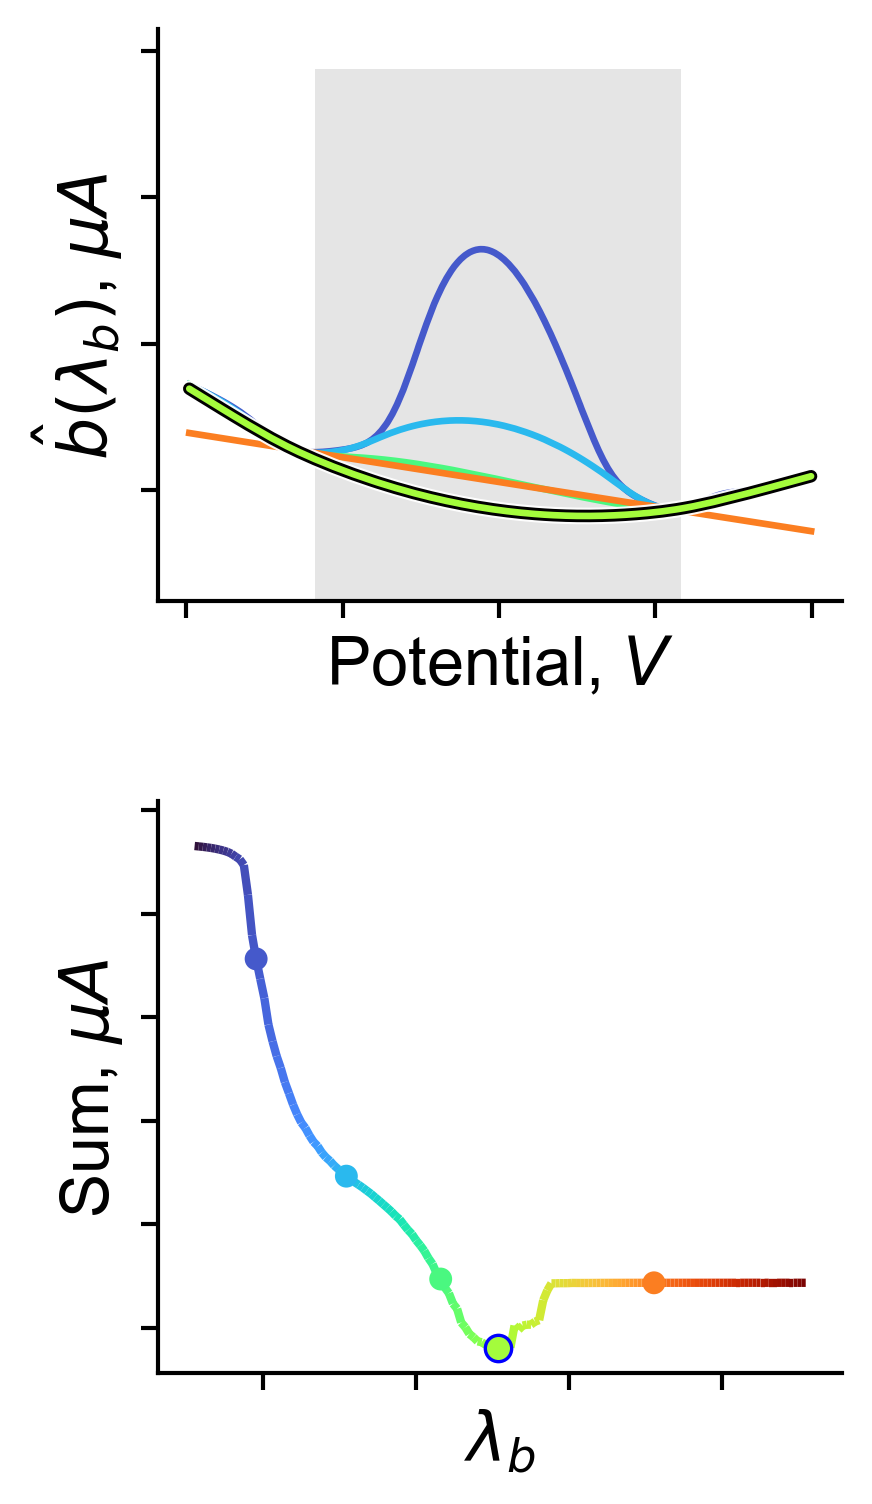

baseline decades each side: 4.0
baseline fractions: (0.1, 0.25, 0.4, 0.75)
baseline lambda color position: 0.500


In [22]:

bl_fitter = Baseline(x_data=volts)

# --------------------------------------------------
# centered lambda grid around the already-selected optimum
# --------------------------------------------------
STEP = "baseline"
lams = lambda_grid_around(lam_bl, step=STEP)
norm = lambda_norm_around(lam_bl, step=STEP)
cmap = TURBO_CMAP

# --------------------------------------------------
# compute baseline curves and objective values for centered grid
# --------------------------------------------------
peak_indices_bl = np.zeros_like(g, dtype=bool)
peak_indices_bl[lower:upper] = True

baselines = []
areas = []

for lam in lams:
    b_temp, ds_params = bl_fitter.derpsalsa(g, lam=lam)
    baselines.append(b_temp)

    # Match the spirit of choose_lambda_area: sum baseline inside peak window.
    # If derpsalsa weights are available, reject pathological fits that lose
    # support on one side of the peak.
    weights = ds_params.get("weights", None)
    if weights is not None:
        threshold = 0.1
        _, _, peak_idx_bl = get_background_range(g, rel_height=1.0)
        has_left = np.any(weights[:peak_idx_bl] > threshold)
        has_right = np.any(weights[peak_idx_bl:] > threshold)
        area = np.sum(b_temp[peak_indices_bl]) if (has_left and has_right) else np.nan
    else:
        area = np.sum(b_temp[peak_indices_bl])

    areas.append(area)

baselines = np.asarray(baselines)
areas = np.asarray(areas)

# selected lambda index
bl_idx = np.argmin(np.abs(lams - lam_bl))

# representative lambdas chosen by fractional position across the centered grid
rep_idx = fraction_indices(len(lams), step=STEP)
rep_idx = rep_idx[rep_idx != bl_idx]

# --------------------------------------------------
# plot
# --------------------------------------------------
fig, axes = plt.subplots(
    2, 1,
    figsize=(3, 8*2/3),
)

# ===== Top panel =====
ax = axes[0]

if lambda_setting(STEP, "show_reference_trace", False):
    ax.plot(volts, g, color="black", lw=0.3, alpha=0.35, zorder=1)

for idx in rep_idx:
    ax.plot(
        volts,
        baselines[idx],
        color=lambda_color(lams[idx], norm),
        lw=1.6,
        zorder=2
    )

plot_optimal_lambda_curve(
    ax,
    volts,
    baselines[bl_idx],
    color=lambda_color(lam_bl, norm),
    zorder=8
)

ax.axvspan(
    volts[lower], volts[upper],
    color="gray",
    alpha=0.2,
    linewidth=0,
    ymin=0.0, ymax=0.93,
    zorder=0
)

ax.set_ylabel(r"$\hat{b}(\lambda_b)$, $\mu A$")
ax.set_xlabel(r"Potential, $V$")
ax.set_yticks(y_ticks)
ax.set_ylim(y_lim)

# ===== Bottom panel =====
ax = axes[1]

valid = np.isfinite(lams) & np.isfinite(areas) & (lams > 0)
lams_plot = lams[valid]
areas_plot = areas[valid]

if lams_plot.size < 2:
    raise RuntimeError("Too few finite baseline objective values to plot.")

valid_orig_idx = np.flatnonzero(valid)

rep_idx_plot = np.array(
    [np.where(valid_orig_idx == i)[0][0] for i in rep_idx if i in valid_orig_idx],
    dtype=int
)
bl_idx_plot = int(np.argmin(np.abs(lams_plot - lam_bl)))

lc = make_colored_line_collection(lams_plot, areas_plot, lams_plot, norm, linewidth=2.0)

ax.set_xscale("log")
ax.add_collection(lc)

ax.set_xlim(norm.vmin / 3, norm.vmax * 3)

ymin = np.nanmin(areas_plot)
ymax = np.nanmax(areas_plot)
ypad = 0.05 * (ymax - ymin) if ymax > ymin else 1.0
ax.set_ylim(ymin - ypad, ymax + ypad)

ax.scatter(
    lams_plot[rep_idx_plot],
    areas_plot[rep_idx_plot],
    color=[lambda_color(lams_plot[i], norm) for i in rep_idx_plot],
    s=22,
    zorder=3,
    linewidths=0.8
)

ax.scatter(
    lams_plot[bl_idx_plot],
    areas_plot[bl_idx_plot],
    color=[lambda_color(lam_bl, norm)],
    s=40,
    zorder=4,
    edgecolors="blue",
    linewidths=0.8
)

ax.set_xlabel(r"$\lambda_b$")
ax.set_ylabel(r"Sum, $\mu A$")

ymin, ymax = ax.get_ylim()
ax.set_ylim(ymin, ymax * 1.01)

save_path = '/Users/Max_1/Soh Lab/figures/derpsalsa/1e.png'
plt.savefig(save_path, transparent=True)
plt.show()

print(f"baseline decades each side: {lambda_setting(STEP, 'decades_each_side')}")
print(f"baseline fractions: {lambda_setting(STEP, 'fractions')}")
print(f"baseline lambda color position: {float(norm(lam_bl)):.3f}")



/var/folders/j4/r_tjgvn15y16clpqr_5grrbc0000gn/T/ipykernel_36593/1090633423.py:34: RuntimeWarning: divide by zero encountered in matmul
  J2 = np.linalg.norm(D@g)**2
/var/folders/j4/r_tjgvn15y16clpqr_5grrbc0000gn/T/ipykernel_36593/1090633423.py:34: RuntimeWarning: overflow encountered in matmul
  J2 = np.linalg.norm(D@g)**2
/var/folders/j4/r_tjgvn15y16clpqr_5grrbc0000gn/T/ipykernel_36593/1090633423.py:34: RuntimeWarning: invalid value encountered in matmul
  J2 = np.linalg.norm(D@g)**2


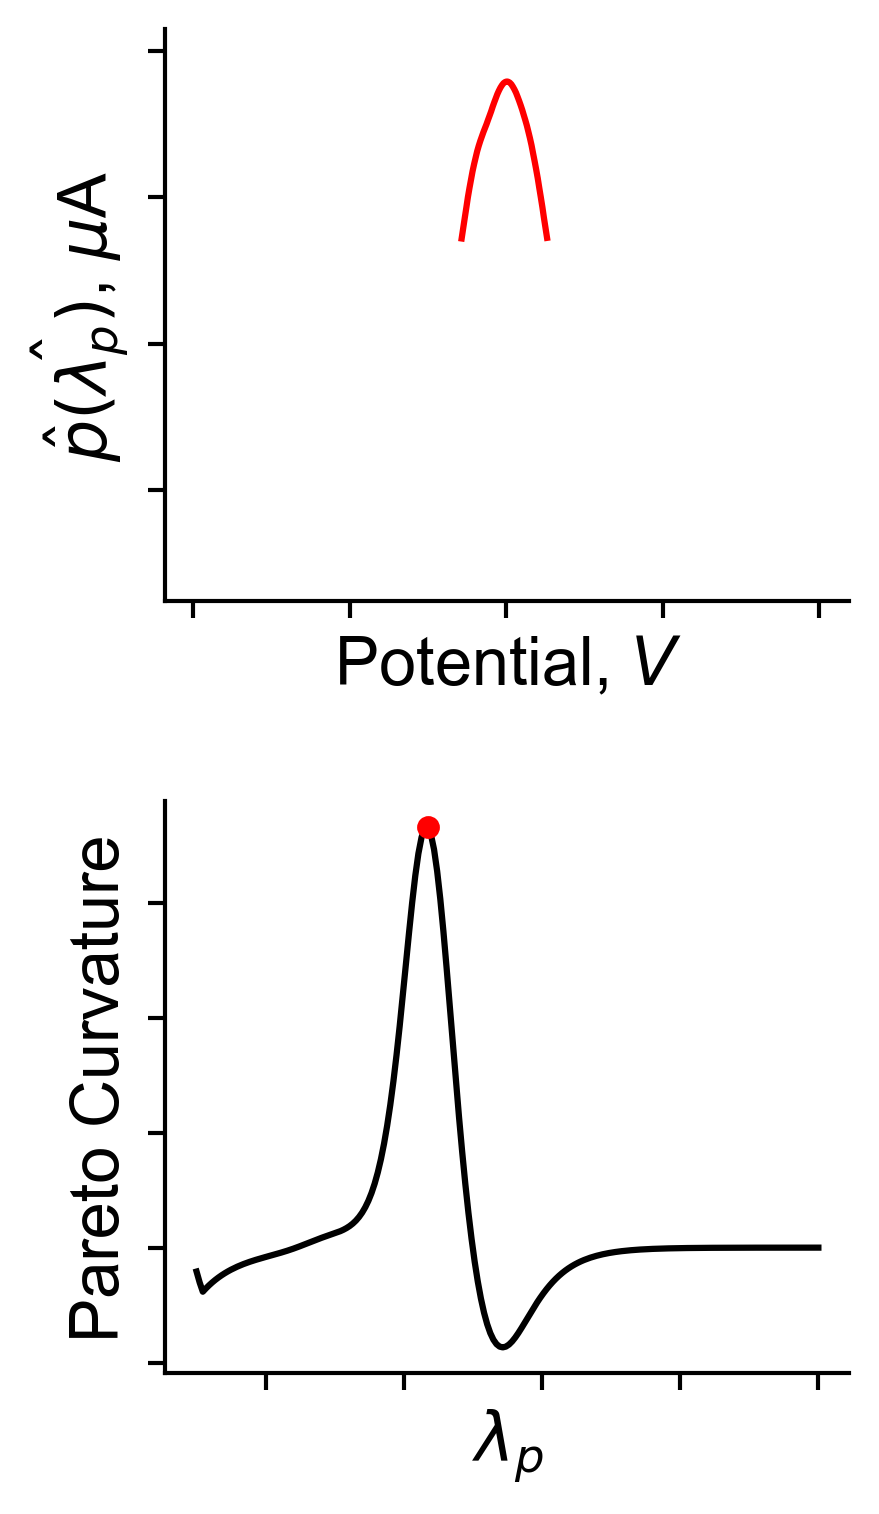

In [23]:
lower50, upper50, _ = get_background_range(g, rel_height=0.3)
peak_indices = np.zeros_like(current, dtype=bool)
peak_indices[lower50:upper50] = 1
lam_peak, g_peak, params_peak = huber_reweighted_lcurve(current[peak_indices] - background[peak_indices], g[peak_indices], n_grid=200)
g_full = np.zeros_like(current)
g_full[peak_indices] = g_peak
peak_idx = np.argmax(g_full)
lams = params_peak['lams']
kappa = params_peak['kappa']
D_peak = second_diff_matrix(int(np.sum(peak_indices)))
J1s = []
J2s = []

for lam in lams[:100]:
    g_temp = smooth_data(y[peak_indices], lam)
    J1, J2 = multi_obj_error(y[peak_indices], g_temp, D_peak)
    J1s.append(J1)
    J2s.append(J2)

fig, axes = plt.subplots(
    2, 1,
    figsize=(3, 8*2/3),
)

ax = axes[0]
fitted = g_peak+background[peak_indices]
ax.plot(volts[peak_indices], fitted, color="red")
ax.set_xlabel(r"Potential, $V$")
ax.set_ylabel(r"$\hat{p}(\hat{\lambda_p})$, $\mu$A")
ax.set_yticks(y_ticks)
ax.set_ylim(y_lim)
ax.set_xticks(x_ticks)
ax.set_xlim(x_lim)

ax = axes[1]
ax.plot(lams, kappa, color='black')
lcurve_idx = np.argmin(np.abs(lams - lam_peak))
ax.scatter(lam_peak, kappa[lcurve_idx], s=20, zorder=3, color='red')
ax.set_xscale('log')
ax.set_xlabel(r"$\lambda_p$")
ax.set_ylabel(r"Pareto Curvature")

for ax in axes:
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

save_path = '/Users/Max_1/Soh Lab/figures/derpsalsa/1f.png'
plt.savefig(save_path, transparent=True)
plt.show()

/var/folders/j4/r_tjgvn15y16clpqr_5grrbc0000gn/T/ipykernel_36593/1090633423.py:34: RuntimeWarning: divide by zero encountered in matmul
  J2 = np.linalg.norm(D@g)**2
/var/folders/j4/r_tjgvn15y16clpqr_5grrbc0000gn/T/ipykernel_36593/1090633423.py:34: RuntimeWarning: overflow encountered in matmul
  J2 = np.linalg.norm(D@g)**2
/var/folders/j4/r_tjgvn15y16clpqr_5grrbc0000gn/T/ipykernel_36593/1090633423.py:34: RuntimeWarning: invalid value encountered in matmul
  J2 = np.linalg.norm(D@g)**2


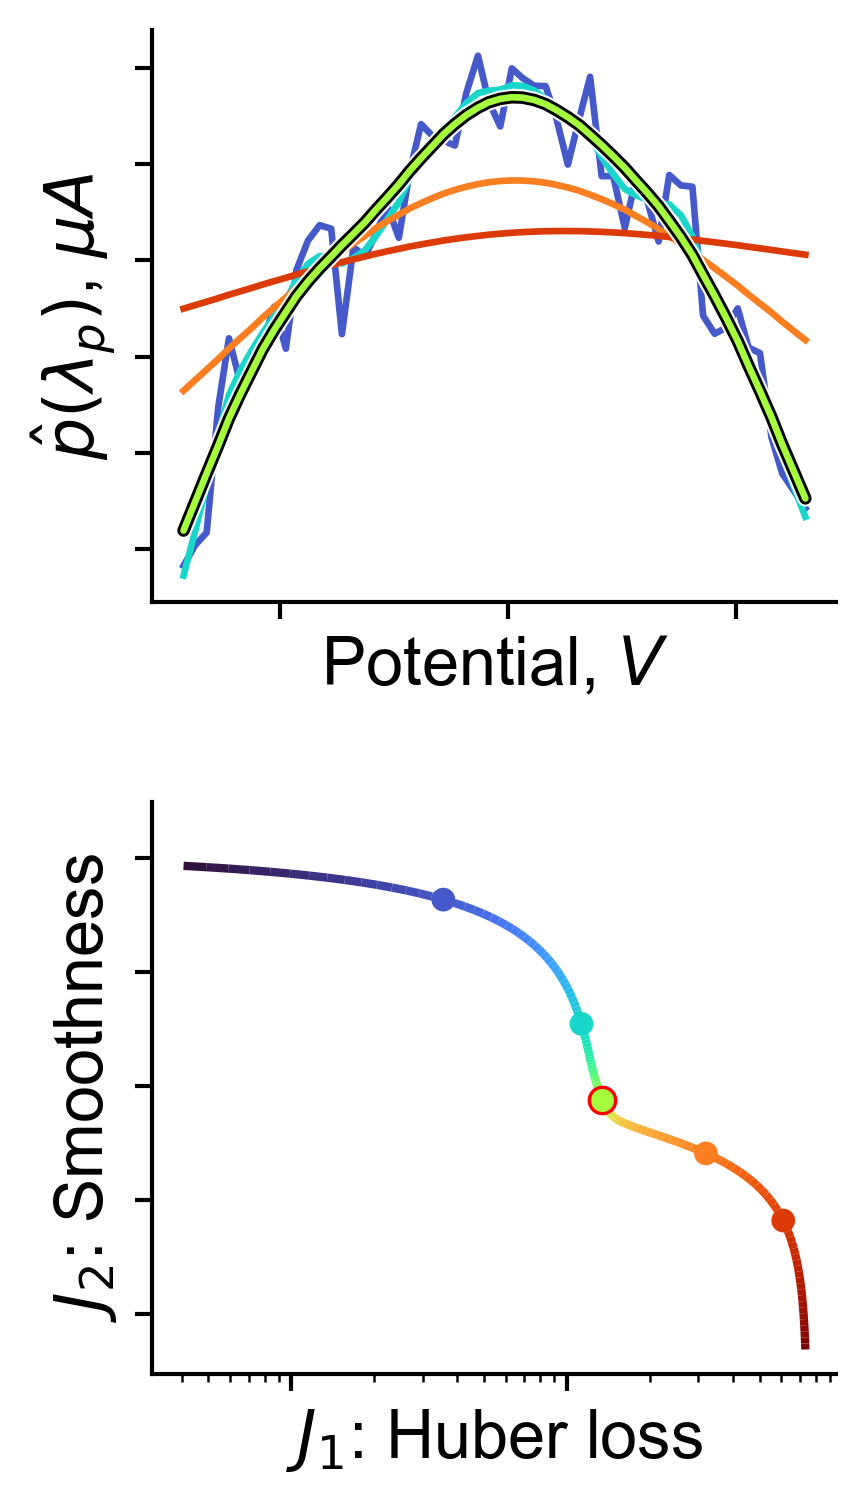

peak decades each side: 4.0
peak fractions: (0.1, 0.3, 0.75, 0.85)
peak lambda color position: 0.500


In [24]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection

# --------------------------------------------------
# peak-only region P_0.5
# --------------------------------------------------
lower50, upper50, _ = get_background_range(g, rel_height=0.3)

peak_indices = np.zeros_like(current, dtype=bool)
peak_indices[lower50:upper50] = True

x_peak = volts[peak_indices]
y_peak = current[peak_indices] - background[peak_indices]
g_peak_init = g[peak_indices]

# Keep the original optimal lambda selection.
lam_peak, g_peak, params_peak = huber_reweighted_lcurve(
    y_peak,
    g_peak_init,
    n_grid=150,
    lam_bounds=(1e-1, 1e6)
)

# --------------------------------------------------
# centered lambda grid around the already-selected optimum
# --------------------------------------------------
STEP = "peak"
lams = lambda_grid_around(lam_peak, step=STEP)
norm = lambda_norm_around(lam_peak, step=STEP)
cmap = TURBO_CMAP

D_peak = second_diff_matrix(y_peak.size)

# --------------------------------------------------
# compute peak-only smoothed curves and objectives
# --------------------------------------------------
J1s = []
J2s = []
gs = []

for lam in lams:
    g_temp = smooth_data(y_peak, lam)
    gs.append(g_temp)
    J1, J2 = multi_obj_error(y_peak, g_temp, D_peak)
    J1s.append(J1)
    J2s.append(J2)

J1s = np.asarray(J1s)
J2s = np.asarray(J2s)
gs = np.asarray(gs)

# selected lambda index
lcurve_idx = np.argmin(np.abs(lams - lam_peak))

# representative lambdas chosen by fractional position across the centered grid
rep_idx = fraction_indices(len(lams), step=STEP)
rep_idx = rep_idx[rep_idx != lcurve_idx]

# --------------------------------------------------
# build colored Pareto frontier
# --------------------------------------------------
pts = np.column_stack([J1s, J2s]).reshape(-1, 1, 2)
segments = np.concatenate([pts[:-1], pts[1:]], axis=1)

lc = make_colored_line_collection(J1s, J2s, lams, norm, linewidth=2.0)

# --------------------------------------------------
# plot
# --------------------------------------------------
fig, axes = plt.subplots(
    2, 1,
    figsize=(3, 8*2/3),
)

# ===== Top panel =====
ax = axes[0]

if lambda_setting(STEP, "show_reference_trace", False):
    ax.plot(x_peak, y_peak, color="black", lw=0.4, alpha=0.35, zorder=1)

for idx in rep_idx:
    ax.plot(
        x_peak,
        gs[idx],
        color=lambda_color(lams[idx], norm),
        lw=1.6,
        zorder=2
    )

plot_optimal_lambda_curve(
    ax,
    x_peak,
    gs[lcurve_idx],
    color=lambda_color(lam_peak, norm),
    zorder=8
)

ax.set_xlabel(r"Potential, $V$")
ax.set_ylabel(r"$\hat{p}({\lambda_p})$, $\mu A$")

# ===== Bottom panel =====
ax = axes[1]

ax.add_collection(lc)

ax.scatter(
    J1s[rep_idx],
    J2s[rep_idx],
    color=[lambda_color(lams[i], norm) for i in rep_idx],
    s=22,
    zorder=3
)

ax.scatter(
    J1s[lcurve_idx],
    J2s[lcurve_idx],
    color=[lambda_color(lam_peak, norm)],
    s=40,
    edgecolors='red',
    linewidths=0.8,
    zorder=4
)

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r"$J_1$: Huber loss")
ax.set_ylabel(r"$J_2$: Smoothness")

ymin, ymax = ax.get_ylim()
ax.set_ylim(ymin, ymax * 5)

for ax in axes:
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

save_path = '/Users/Max_1/Soh Lab/figures/derpsalsa/1g.png'
plt.savefig(save_path, transparent=True)
plt.show()

print(f"peak decades each side: {lambda_setting(STEP, 'decades_each_side')}")
print(f"peak fractions: {lambda_setting(STEP, 'fractions')}")
print(f"peak lambda color position: {float(norm(lam_peak)):.3f}")



/var/folders/j4/r_tjgvn15y16clpqr_5grrbc0000gn/T/ipykernel_36593/1090633423.py:34: RuntimeWarning: divide by zero encountered in matmul
  J2 = np.linalg.norm(D@g)**2
/var/folders/j4/r_tjgvn15y16clpqr_5grrbc0000gn/T/ipykernel_36593/1090633423.py:34: RuntimeWarning: overflow encountered in matmul
  J2 = np.linalg.norm(D@g)**2
/var/folders/j4/r_tjgvn15y16clpqr_5grrbc0000gn/T/ipykernel_36593/1090633423.py:34: RuntimeWarning: invalid value encountered in matmul
  J2 = np.linalg.norm(D@g)**2


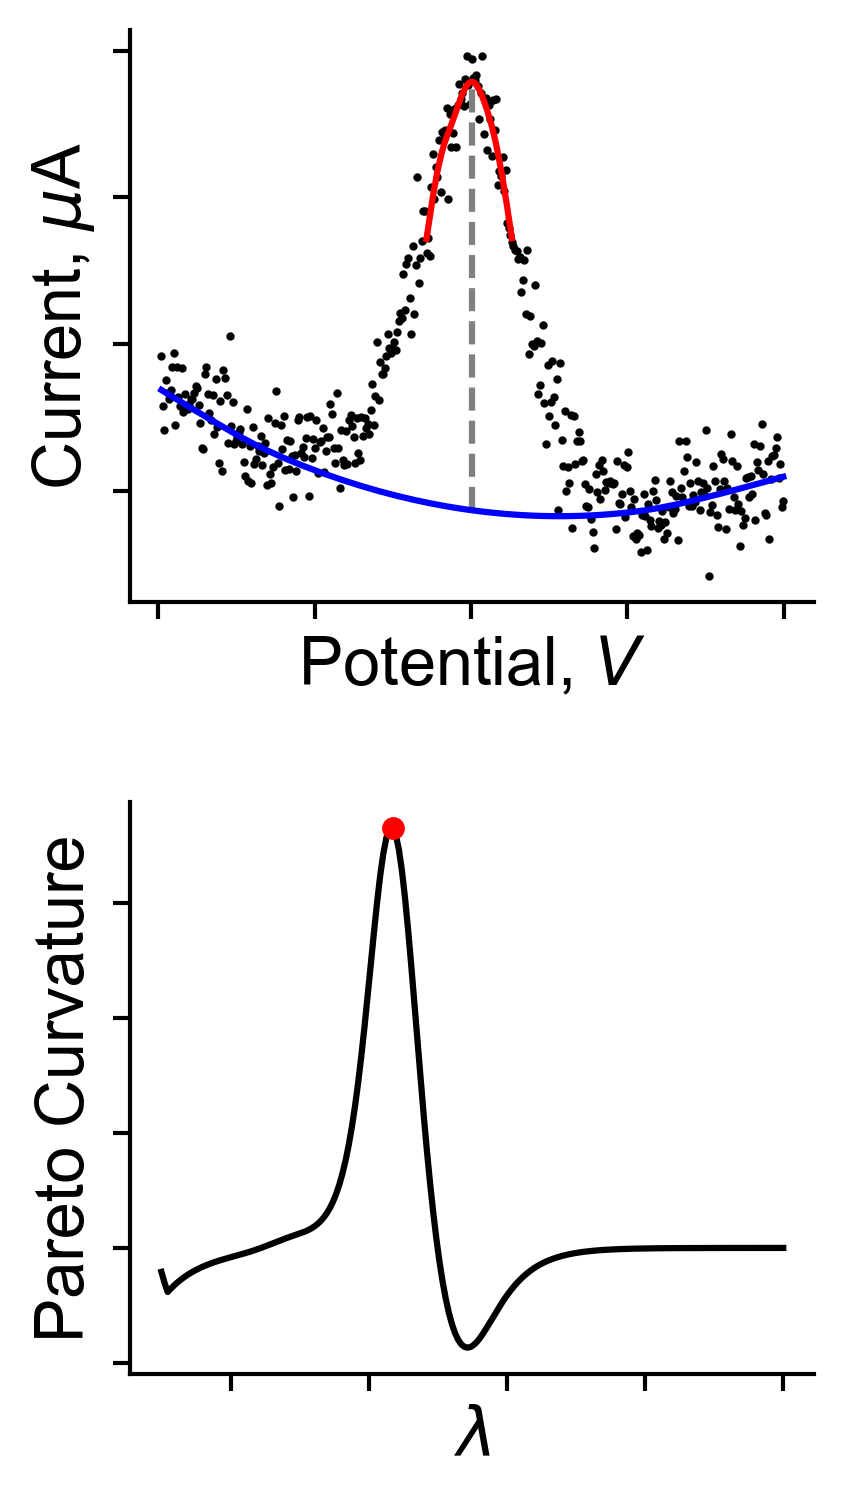

In [25]:
lower50, upper50, _ = get_background_range(g, rel_height=0.3)
peak_indices = np.zeros_like(current, dtype=bool)
peak_indices[lower50:upper50] = 1
lam_peak, g_peak, params_peak = huber_reweighted_lcurve(current[peak_indices] - background[peak_indices], g[peak_indices], n_grid=200)
g_full = np.zeros_like(current)
g_full[peak_indices] = g_peak
peak_idx = np.argmax(g_full)
lams = params_peak['lams']
kappa = params_peak['kappa']
D_peak = second_diff_matrix(int(np.sum(peak_indices)))
J1s = []
J2s = []

for lam in lams[:100]:
    g_temp = smooth_data(y[peak_indices], lam)
    J1, J2 = multi_obj_error(y[peak_indices], g_temp, D_peak)
    J1s.append(J1)
    J2s.append(J2)

fig, axes = plt.subplots(
    2, 1,
    figsize=(3, 8*2/3),
)

ax = axes[0]
fitted = g_peak+background[peak_indices]
ax.vlines(volts[peak_idx], ymin=background[peak_idx], ymax=background[peak_idx]+g_full[peak_idx], color='grey', linestyle='--')
ax.plot(volts[peak_indices], fitted, color="red")
ax.plot(volts, background, color='blue')
ax.set_xlabel(r"Potential, $V$")
ax.set_ylabel(r"Current, $\mu$A")
ax.scatter(volts, current, color='black', s=1)
ax.set_yticks(y_ticks)
ax.set_ylim(y_lim)


ax = axes[1]
ax.plot(lams, kappa, color='black')
lcurve_idx = np.argmin(np.abs(lams - lam_peak))
ax.scatter(lam_peak, kappa[lcurve_idx], s=20, zorder=3, color='red')
ax.set_xscale('log')
ax.set_xlabel(r"$\lambda$")
ax.set_ylabel(r"Pareto Curvature")

for ax in axes:
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

save_path = '/Users/Max_1/Soh Lab/figures/derpsalsa/1h.png'
plt.savefig(save_path, transparent=True)
plt.show()

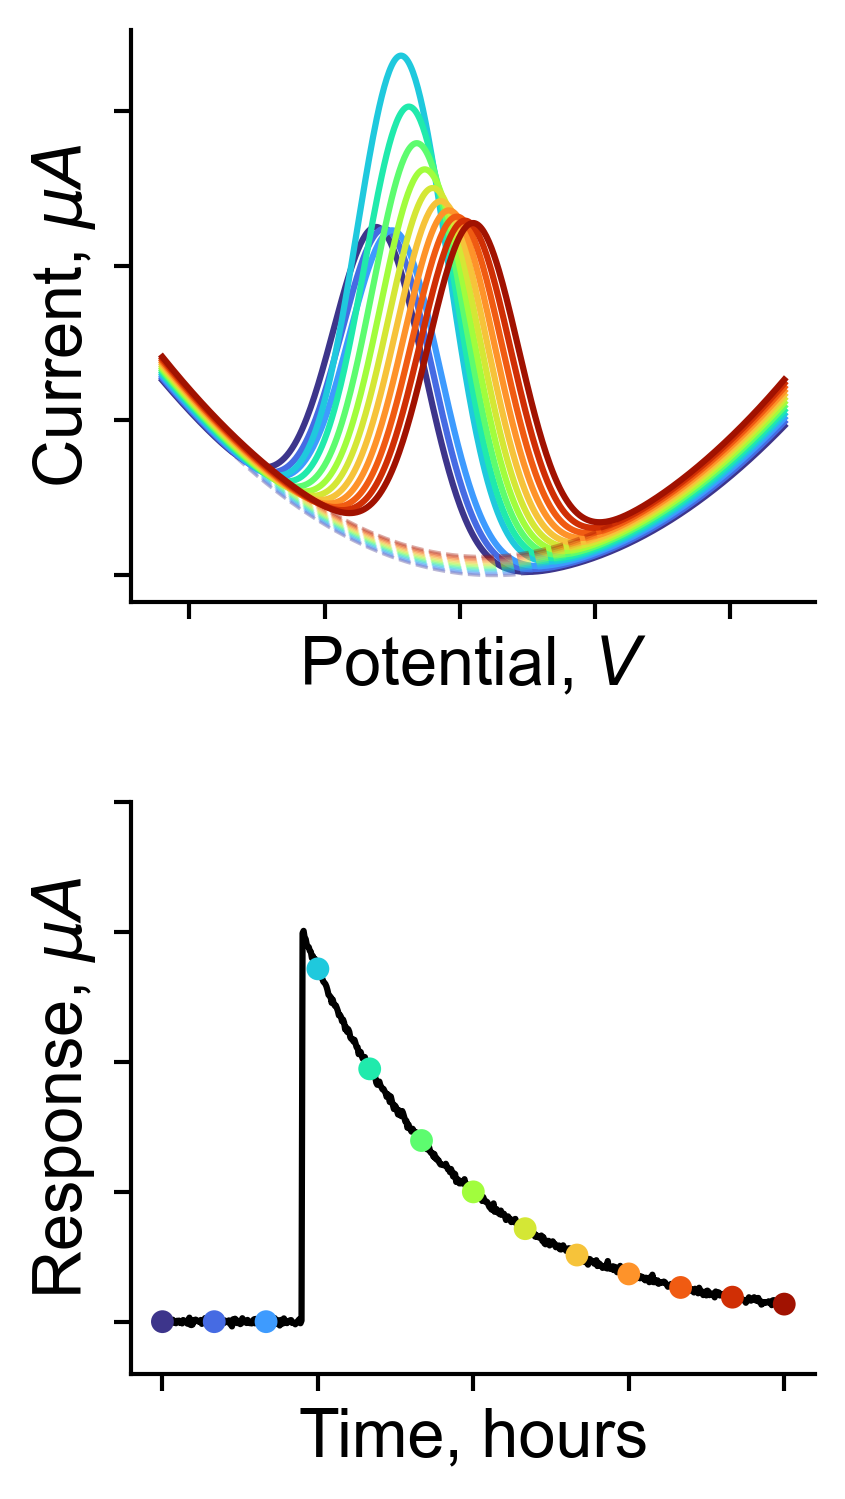

In [26]:
# -----------------------------
# Synthetic Figure 1i settings
# -----------------------------
rng = np.random.default_rng(2)

n_traces = 13
cmap = TURBO_CMAP if "TURBO_CMAP" in globals() else cm.get_cmap("turbo")
colors = cmap(np.linspace(0.05, 0.95, n_traces))

fig, axes = plt.subplots(
    2, 1,
    figsize=(3, 8*2/3),
)

# ==================================================
# Shared pharmacokinetic trend used for both panels
# ==================================================
time = np.linspace(0, 4.0, 600)
sample_times = np.linspace(time.min(), time.max(), n_traces)

t_inj = 0.9
baseline_response = 1.0
amplitude = 0.6
tau_decay = 1.0


def pharmacokinetic_response(t):
    """Stable baseline followed by a spike and exponential return to baseline."""
    t = np.asarray(t, dtype=float)
    response = np.full_like(t, baseline_response, dtype=float)
    post_inj = t >= t_inj
    response[post_inj] = (
        baseline_response
        + amplitude * np.exp(-(t[post_inj] - t_inj) / tau_decay)
    )
    return response


response = pharmacokinetic_response(time)
response_noisy = response + rng.normal(0, 0.003, size=time.size)
sample_response = pharmacokinetic_response(sample_times)

# ==================================================
# Top panel: evolving smoothed voltammograms
# ==================================================
ax = axes[0]

volts = np.linspace(-0.42, 0.04, 500)
v0 = volts - volts.mean()
frac_trace = np.linspace(0, 1, n_traces)

# Convex polynomial baseline. The baseline drifts slowly with acquisition
# number, but the fitted peak height follows sample_response below.
base_poly = (
    0.050
    - 0.032 * v0
    + 1.05 * v0**2
)

base_peak_height = 0.105
peak_sigma = 0.034

for i, (frac, resp_i) in enumerate(zip(frac_trace, sample_response)):
    baseline = (
        base_poly
        + 0.006 * frac
        + 0.016 * frac * v0
        + 0.10 * frac * v0**2
    )

    # Peak location shifts with acquisition time, while peak width remains fixed.
    peak_center = -0.260 + 0.070 * frac
    peak_height = base_peak_height * resp_i

    peak = peak_height * np.exp(
        -0.5 * ((volts - peak_center) / peak_sigma) ** 2
    )

    trace = baseline + peak

    ax.plot(
        volts,
        trace,
        color=colors[i],
        lw=1.5,
    )

    ax.plot(
        volts,
        baseline,
        color=colors[i],
        lw=0.8,
        alpha=0.35,
        linestyle="--",
    )

ax.set_xlabel(r"Potential, $V$")
ax.set_ylabel(r"Current, $\mu A$")

# ==================================================
# Bottom panel: normalized pharmacokinetic response
# ==================================================
ax = axes[1]

ax.plot(time, response_noisy, color="black", lw=1.5)
ax.scatter(
    sample_times,
    sample_response,
    color=colors,
    s=30,
    zorder=3,
    linewidths=0,
)

ax.set_xlabel("Time, hours")
ax.set_ylabel(r"Response, $\mu A$")
ax.set_ylim(0.92, 1.8)

# ==================================================
# Shared ASWIFT-style formatting
# ==================================================
for ax in axes:
    ax.tick_params(labelbottom=False, labelleft=False)

    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

save_path = "/Users/Max_1/Soh Lab/figures/derpsalsa/1i.png"
plt.savefig(save_path, transparent=True)
plt.show()

